# Support Vector Machines

We wil implement both hard-margin SVMs and soft-margin SVMs from scratch on a toy dataset. Apart from `NumPy`, we would need to take the help of `SciPy` for solving the quadratic programming problem.

## Hard-Margin SVM

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [12, 12]

In [2]:
#### DATA: DO NOT EDIT THIS CELL ####
X = np.array([[1, -3], [1, 0], [4, 1], [3, 7], [0, -2],
             [-1, -6], [2, 5], [1, 2], [0, -1], [-1, -4],
             [0, 7], [1, 5], [-4, 4], [2, 9], [-2, 2],
             [-2, 0], [-3, -2], [-2, -4], [3, 10], [-3, -8]]).T
y = np.array([1, 1, 1, 1, 1,
             1, 1, 1, 1, 1,
             -1, -1, -1, -1, -1,
             -1, -1, -1, -1, -1])

### Problem-1

$\mathbf{X}$ is a data-matrix of shape $(d, n)$. $\mathbf{y}$ is a vector of labels of size $(n, )$. What is the value of $n$ and $d$?

In [3]:
### Solution ###
d, n = X.shape
print(f"The data matrix X has dimensions (d, n) = ({d}, {n}).")
print(f"The label vector y has length n = {y.shape[0]}.")

The data matrix X has dimensions (d, n) = (2, 20).
The label vector y has length n = 20.


### Problem-2

Visualize the dataset given to you using a scatter plot. Colour points which belong to class $+1$ $\color{green}{\text{green}}$ and those that belong to $-1$ $\color{red}{\text{red}}$. Inspect the data visually and determine its linear separability.

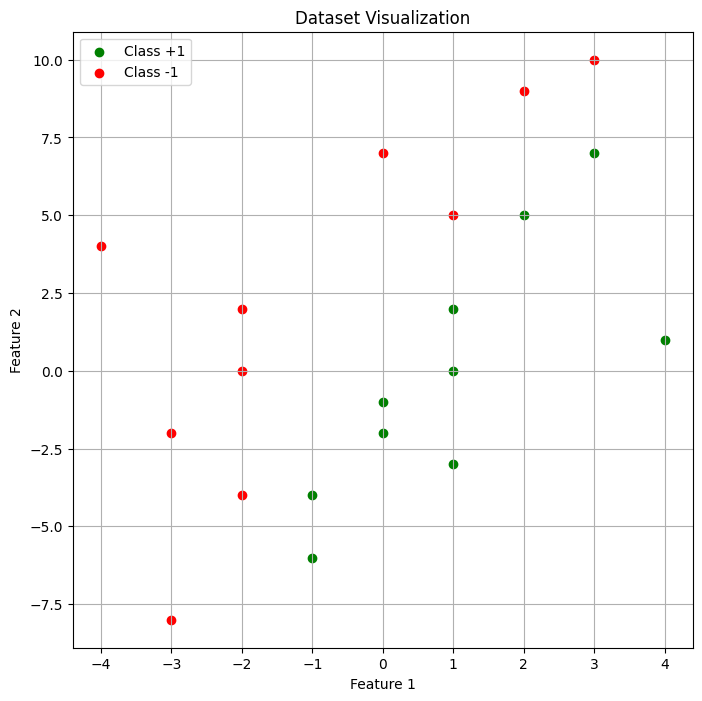

From visual inspection, the data appears to be linearly separable, as a straight line can clearly separate the green points from the red points.


In [4]:
### Solution ###

# Separate points based on labels
X_class_1 = X[:, y == 1]
X_class_neg1 = X[:, y == -1]

# Create the scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(X_class_1[0, :], X_class_1[1, :], color='green', label='Class +1')
plt.scatter(X_class_neg1[0, :], X_class_neg1[1, :], color='red', label='Class -1')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset Visualization')
plt.legend()
plt.grid(True)
plt.show()

print("From visual inspection, the data appears to be linearly separable, as a straight line can clearly separate the green points from the red points.")

### Problem-3

Compute the object $\mathbf{Y}$ that appears in the dual problem. What kind of an object is $\mathbf{Y}$?

In [5]:
### Solution ###
Y = np.diag(y)
print("The object Y is a diagonal matrix where the diagonal elements are the labels y.")
print(f"Its shape is {Y.shape}.")

The object Y is a diagonal matrix where the diagonal elements are the labels y.
Its shape is (20, 20).


### Problem-4

Let $\boldsymbol{\alpha}$ be the dual variable. The dual objective is of the form:

$$
f(\boldsymbol{\alpha}) = \boldsymbol{\alpha}^T \mathbf{1} - \cfrac{1}{2} \cdot \boldsymbol{\alpha}^T \mathbf{Q} \boldsymbol{\alpha}
$$



Compute the matrix $\mathbf{Q}$ for this problem and find the sum of its elements. What properties does the matrix $\mathbf{Q}$ have? What is the nature of the objective function?

In [6]:
### Solution ###

# Compute the Gram matrix K = X.T @ X
K = X.T @ X

# Compute Q. Y is np.diag(y)
Q = Y @ K @ Y

print(f"The matrix Q has shape {Q.shape}.")
print(f"The sum of the elements of Q is: {np.sum(Q):.2f}")

print("\nProperties of matrix Q:")
print("1. Q is a symmetric matrix: Q = Q.T (since Y is diagonal and K is symmetric). This can be verified by checking if np.allclose(Q, Q.T).")
print("2. Q is positive semi-definite (PSD). This is because K (Gram matrix) is PSD, and Q is constructed by multiplying K by diagonal matrices Y. This ensures the objective function is convex (for minimization) or concave (for maximization).")

print("\nNature of the objective function f(alpha) = alpha^T * 1 - (1/2) * alpha^T * Q * alpha:")
print("Since Q is positive semi-definite, the term -(1/2) * alpha^T * Q * alpha is a concave function. Therefore, the objective function f(alpha) is concave. We are maximizing a concave function, which is a convex optimization problem.")

The matrix Q has shape (20, 20).
The sum of the elements of Q is: 976.00

Properties of matrix Q:
1. Q is a symmetric matrix: Q = Q.T (since Y is diagonal and K is symmetric). This can be verified by checking if np.allclose(Q, Q.T).
2. Q is positive semi-definite (PSD). This is because K (Gram matrix) is PSD, and Q is constructed by multiplying K by diagonal matrices Y. This ensures the objective function is convex (for minimization) or concave (for maximization).

Nature of the objective function f(alpha) = alpha^T * 1 - (1/2) * alpha^T * Q * alpha:
Since Q is positive semi-definite, the term -(1/2) * alpha^T * Q * alpha is a concave function. Therefore, the objective function f(alpha) is concave. We are maximizing a concave function, which is a convex optimization problem.


### Problem-5

Since `SciPy`'s optimization routines take the form of minimizing a function, we will recast $f$ as follows:

$$
f(\boldsymbol{\alpha}) =  \cfrac{1}{2} \cdot \boldsymbol{\alpha}^T \mathbf{Q} \boldsymbol{\alpha} - \boldsymbol{\alpha}^T \mathbf{1}
$$

We now have to solve :

$$
\min \limits_{\boldsymbol{\alpha} \geq 0} \quad f(\boldsymbol{\alpha})
$$

Note that $\max$ changes to $\min$ since we changed the sign of the objective function.

<hr>

Write a function `loss` that returns the value of objective function $f(\boldsymbol{\alpha})$ for argument $\boldsymbol{\alpha}$. Compute the value of `loss` at $\boldsymbol{\alpha} = \mathbf{1}$.

**Note**: The reason for naming the function `loss` is that we will be using `SciPy`'s `scipy.optimize.minize` routine.

In [7]:
### Solution ###

def loss(alpha):
    # Reshape alpha to be a column vector if it's not already
    alpha = alpha.reshape(-1, 1)
    # f(alpha) = (1/2) * alpha.T @ Q @ alpha - alpha.T @ 1
    return 0.5 * alpha.T @ Q @ alpha - alpha.T @ np.ones((n, 1))

# Compute the value of loss at alpha = 1 (vector of ones)
alpha_one = np.ones(n) # n is the number of samples
loss_at_one = loss(alpha_one)
print(f"The value of loss at alpha = 1 is: {loss_at_one[0,0]:.2f}")

The value of loss at alpha = 1 is: 468.00


### Problem-6

Write a function named `jac` that computes the gradient, $\nabla f(\boldsymbol{\alpha})$, given $\boldsymbol{\alpha}$ as argument. Compute the value of `jac` at $\boldsymbol{\alpha} = \mathbf{1}$ and print the sum of the components of the gradient vector.

**Note**: `jac` stands for Jacobian. In our case, we don't have a vector valued function. So, this will just be the gradient.

In [10]:
### Solution ###
def jac(alpha):
    # Reshape alpha to be a column vector if it's not already
    alpha = alpha.reshape(-1, 1)
    # Gradient is Q @ alpha - 1
    # Ensure the output is a 1D array for scipy.optimize.minimize
    return (Q @ alpha - np.ones((n, 1))).ravel()

# Compute the value of jac at alpha = 1 (vector of ones)
gradient_at_one = jac(alpha_one)

# Print the sum of the components of the gradient vector
print(f"The sum of the components of the gradient at alpha = 1 is: {np.sum(gradient_at_one):.2f}")

The sum of the components of the gradient at alpha = 1 is: 956.00


### Problem-7

Finally, we have most of the ingredients to solve the dual problem:

$$
\min \limits_{\boldsymbol{\alpha} \geq 0} \quad \cfrac{1}{2} \cdot \boldsymbol{\alpha}^T \mathbf{Q} \boldsymbol{\alpha} - \boldsymbol{\alpha}^T \mathbf{1}
$$

Go through this [document](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize) to understand how `scipy.optimize.minimize` works. Few pointers:

(1)  You should pass five arguments to `scipy.optimize.minimize`: `loss`, `jac`, `alpha_init`, `method`, `Bounds`

(2) Use the method `SLSQP`. You can treat this as a black-box.

(3) Set the initial value of `alpha_init` to zero.

(4) Use `scipy.optimize.Bounds` to trigger the $\boldsymbol{\alpha} \geq 0$ constraint.

Compute the sum of components of the optimal solution, $\boldsymbol{\alpha}^*$. Enter the nearest integer as your answer.

In [11]:
### Solution ###
from scipy.optimize import minimize, Bounds

# Set the initial value of alpha_init to zero
alpha_init = np.zeros(n)

# Use scipy.optimize.Bounds to trigger the alpha >= 0 constraint
bounds = Bounds(0, np.inf)

# Solve the optimization problem
result = minimize(loss, alpha_init, method='SLSQP', jac=jac, bounds=bounds)

# Optimal alpha values
alpha_star = result.x

# Compute the sum of components of the optimal solution
sum_alpha_star = np.sum(alpha_star)

print(f"The sum of the components of the optimal solution alpha* is: {sum_alpha_star:.2f}")
print(f"The nearest integer is: {round(sum_alpha_star)}")

The sum of the components of the optimal solution alpha* is: 10.00
The nearest integer is: 10


### Problem-8

Find all the support vectors. Print the indices (zero-indexing) in the data-matrix where these support vectors are found.

In [12]:
### Solution ###

# Support vectors are points for which alpha_star > 0
# We use a small epsilon to account for numerical precision issues
epsilon = 1e-6
support_vector_indices = np.where(alpha_star > epsilon)[0]

print(f"The indices of the support vectors are: {support_vector_indices.tolist()}")
print(f"Number of support vectors: {len(support_vector_indices)}")

# Optionally, store the support vectors themselves
support_vectors = X[:, support_vector_indices]
support_vector_labels = y[support_vector_indices]

The indices of the support vectors are: [6, 7, 8, 9, 18, 19]
Number of support vectors: 6


### Problem-9

Find the optimal weight vector $\mathbf{w}^*$. Round each component of the optimal weight vector to the nearest integer.

In [13]:
### Solution ###

# The optimal weight vector w* can be computed as: w* = sum(alpha_i * y_i * x_i) for i in support_vectors
# This can be written in matrix form as w* = X @ (alpha_star * y)
# First, reshape y to be a column vector for element-wise multiplication
alpha_y = alpha_star * y

w_star = X @ alpha_y

print(f"The optimal weight vector w* is: {w_star.round().astype(int).tolist()}")
print(f"Rounded each component of the optimal weight vector to the nearest integer: {w_star.round().astype(int).tolist()}")

The optimal weight vector w* is: [3, -1]
Rounded each component of the optimal weight vector to the nearest integer: [3, -1]


### Problem-10

Plot the decision boundary along with the supporting hyperplanes. Note where the support vectors lie in this plot. How many red points lie on the supporting hyperplanes? How many green points lie on the supporting hyperplanes?

The optimal bias b* is: -0.00


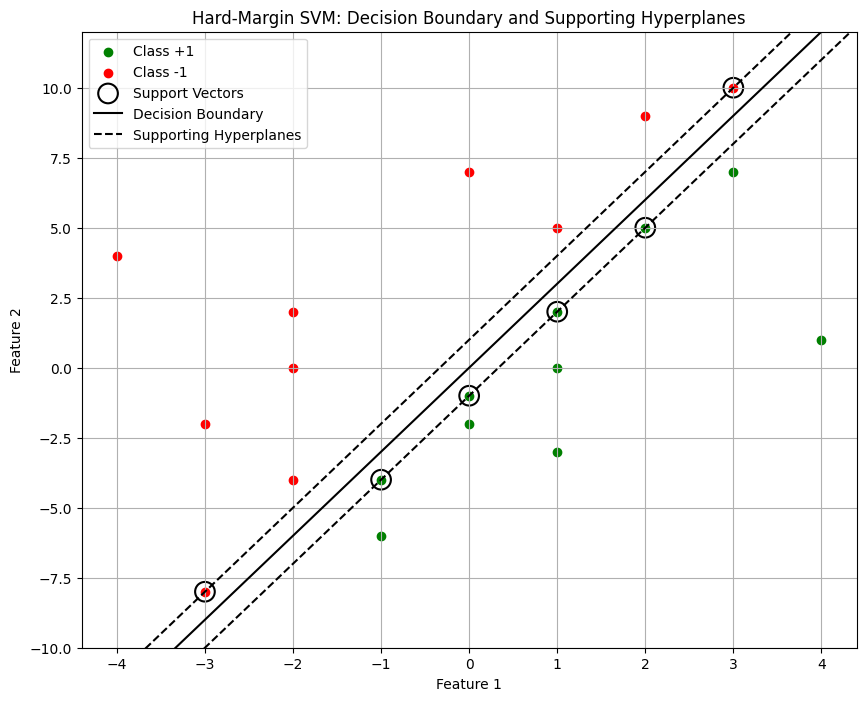

Indices of points on supporting hyperplanes: [6, 7, 8, 9, 18, 19]
Number of red points (class -1) on supporting hyperplanes: 2
Number of green points (class +1) on supporting hyperplanes: 4
Observation: All support vectors lie exactly on the supporting hyperplanes, as expected for a hard-margin SVM.


In [14]:
### Solution ###

# Compute the optimal bias b*
# The bias b* can be found using any support vector (x_s, y_s) such that y_s * (w*.T @ x_s + b*) = 1
# We can pick one support vector, e.g., the first one, for calculation.
# It's better to average over all support vectors for robustness, or use one where alpha is not at a boundary (though for hard margin, all are 'on' the boundary condition)

# Let's find b* using the condition y_s * (w*.T @ x_s + b*) = 1
# From this, b* = 1/y_s - w*.T @ x_s

# Use support vectors where alpha_star is significantly greater than epsilon
# This helps avoid numerical issues with very small alpha_star values that might not truly be support vectors
relevant_support_vector_indices = support_vector_indices[np.where(alpha_star[support_vector_indices] > epsilon * 100)[0]] # Slightly higher threshold

if len(relevant_support_vector_indices) > 0:
    # Pick a support vector (e.g., the first one)
    s_idx = relevant_support_vector_indices[0]
    x_s = X[:, s_idx]
    y_s = y[s_idx]

    b_star = 1/y_s - np.dot(w_star, x_s)
    print(f"The optimal bias b* is: {b_star:.2f}")
else:
    print("No significant support vectors found to compute bias.")
    b_star = 0.0 # Default to 0 if no support vectors

# Plotting the data points
plt.figure(figsize=(10, 8))
plt.scatter(X_class_1[0, :], X_class_1[1, :], color='green', label='Class +1')
plt.scatter(X_class_neg1[0, :], X_class_neg1[1, :], color='red', label='Class -1')

# Plot support vectors with a distinct marker
plt.scatter(support_vectors[0, :], support_vectors[1, :], s=200, facecolors='none', edgecolors='black', linewidth=1.5, label='Support Vectors')

# Plot the decision boundary (w*.T @ x + b* = 0)
# w1*x1 + w2*x2 + b* = 0  => x2 = (-w1*x1 - b*) / w2*

ax_min, ax_max = plt.xlim()
xx = np.linspace(ax_min, ax_max)

w1, w2 = w_star[0], w_star[1]

# Check if w2 is close to zero to avoid division by zero
if np.isclose(w2, 0):
    # Vertical line for decision boundary
    yy_db = (-b_star / w1) * np.ones_like(xx)
    # Supporting hyperplanes
    yy_hp_pos = (1 - b_star) / w1 * np.ones_like(xx)
    yy_hp_neg = (-1 - b_star) / w1 * np.ones_like(xx)
    plt.plot([(-b_star/w1), (-b_star/w1)], plt.ylim(), 'k-', label='Decision Boundary')
    plt.plot([(1-b_star)/w1, (1-b_star)/w1], plt.ylim(), 'k--', label='Supporting Hyperplanes')
    plt.plot([(-1-b_star)/w1, (-1-b_star)/w1], plt.ylim(), 'k--')
else:
    # General case
    yy_db = (-w1 * xx - b_star) / w2
    # Plot the decision boundary
    plt.plot(xx, yy_db, 'k-', label='Decision Boundary')

    # Plot the supporting hyperplanes (w*.T @ x + b* = 1 and w*.T @ x + b* = -1)
    yy_hp_pos = (-w1 * xx - b_star + 1) / w2 # For y_i * (w*.T @ x_i + b*) = 1
    yy_hp_neg = (-w1 * xx - b_star - 1) / w2 # For y_i * (w*.T @ x_i + b*) = -1
    plt.plot(xx, yy_hp_pos, 'k--', label='Supporting Hyperplanes')
    plt.plot(xx, yy_hp_neg, 'k--')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hard-Margin SVM: Decision Boundary and Supporting Hyperplanes')
plt.legend()
plt.grid(True)
plt.xlim(ax_min, ax_max)
plt.ylim(np.min(X[1,:]) - 2, np.max(X[1,:]) + 2) # Adjust y-limits for better visibility
plt.show()

# Count points on supporting hyperplanes
# A point (x_i, y_i) is on a supporting hyperplane if y_i * (w*.T @ x_i + b*) is approximately 1
# We need to account for numerical precision

points_on_hyperplane = []
for i in range(n):
    val = y[i] * (np.dot(w_star, X[:, i]) + b_star)
    if np.isclose(abs(val), 1, atol=1e-3): # Using a tolerance for numerical stability
        points_on_hyperplane.append(i)

red_points_on_hyperplane = [idx for idx in points_on_hyperplane if y[idx] == -1]
green_points_on_hyperplane = [idx for idx in points_on_hyperplane if y[idx] == 1]

print(f"Indices of points on supporting hyperplanes: {points_on_hyperplane}")
print(f"Number of red points (class -1) on supporting hyperplanes: {len(red_points_on_hyperplane)}")
print(f"Number of green points (class +1) on supporting hyperplanes: {len(green_points_on_hyperplane)}")
print("Observation: All support vectors lie exactly on the supporting hyperplanes, as expected for a hard-margin SVM.")


## Soft-margin SVM

We now turn to soft-margin SVMs. Adapt the hard-margin code that you have written for the soft-margin problem. The only change you have to make is to introduce an upper bound for $\boldsymbol{\alpha}$, which is the hyperparameter $C$.


In [15]:
### Solution ###

from scipy.optimize import minimize, Bounds

def solve_soft_margin_svm(C):
    # Set the initial value of alpha_init to zero
    alpha_init_soft = np.zeros(n)

    # For soft-margin SVM, alpha has bounds [0, C]
    bounds_soft = Bounds(0, C)

    # Solve the optimization problem
    result_soft = minimize(loss, alpha_init_soft, method='SLSQP', jac=jac, bounds=bounds_soft)

    # Optimal alpha values for soft-margin
    alpha_star_soft = result_soft.x

    # Compute the optimal weight vector w* for soft-margin
    alpha_y_soft = alpha_star_soft * y
    w_star_soft = X @ alpha_y_soft

    # Compute the optimal bias b* for soft-margin
    # For soft-margin, b* is typically found by averaging over support vectors for which 0 < alpha_i < C
    # A more robust way is to select a support vector where alpha_i is not at the boundary (0 or C)

    # Find support vectors: 0 < alpha_i
    support_vector_indices_soft = np.where(alpha_star_soft > epsilon)[0]

    # Find margin support vectors: 0 < alpha_i < C
    # These are the vectors that define the margin and for which y_i * (w*.T @ x_i + b*) = 1
    margin_sv_indices = np.where((alpha_star_soft > epsilon) & (alpha_star_soft < C - epsilon))[0]

    b_star_soft = 0.0
    if len(margin_sv_indices) > 0:
        # Use margin support vectors to compute b*
        b_values = []
        for idx in margin_sv_indices:
            b_values.append(y[idx] - np.dot(w_star_soft, X[:, idx]))
        b_star_soft = np.mean(b_values)
    elif len(support_vector_indices_soft) > 0: # If no margin SVs, use any SV, but this might be less stable
         s_idx = support_vector_indices_soft[0]
         x_s = X[:, s_idx]
         y_s = y[s_idx]
         b_star_soft = y_s - np.dot(w_star_soft, x_s)
    else:
        print(f"Warning: No support vectors found for C={C}. Defaulting b_star to 0.")

    return alpha_star_soft, w_star_soft, b_star_soft, support_vector_indices_soft

### Problem-11

Plot the decision boundary and the supporting hyperplane for the following values of $C$.

(1) $C = 0.01$

(2) $C = 0.1$

(3) $C = 1$

(4) $C = 10$

Plot all of them in a $2 \times 2$ subplot. Study the tradeoff between the following quantities:

(1) Width of the margin.

(2) Number of points that lie within the margin or on the wrong side. This is often called **margin violation**.


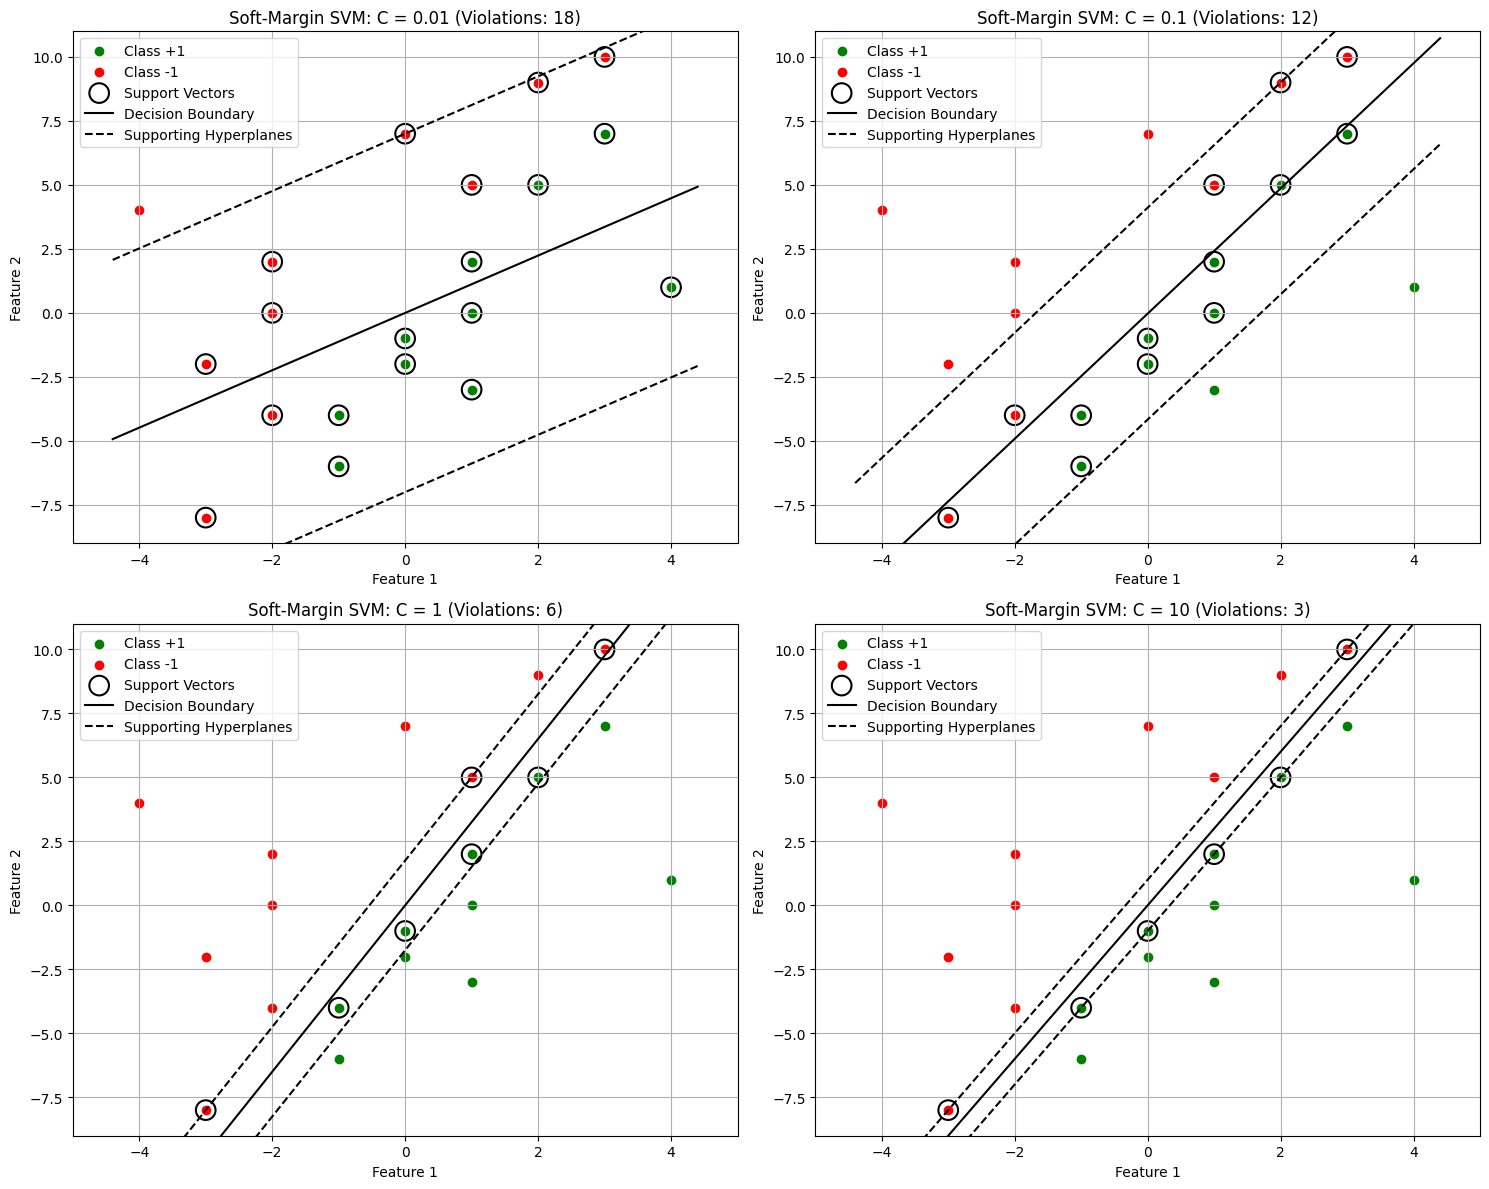

Observation on Trade-off:
As C increases:
  - The margin tends to get narrower. A smaller C allows more violations, leading to a wider margin to generalize better.
  - The number of margin violations tends to decrease. A larger C penalizes violations more, forcing the model to classify training points correctly, even at the cost of a narrower margin.
  - The model becomes less tolerant to misclassifications with larger C, behaving more like a hard-margin SVM.


In [16]:
### Solution ###

C_values = [0.01, 0.1, 1, 10]
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, C in enumerate(C_values):
    alpha_star_soft, w_star_soft, b_star_soft, support_vector_indices_soft = solve_soft_margin_svm(C)

    # Count margin violations
    # A margin violation occurs if y_i * (w*.T @ x_i + b*) < 1 (for soft margin, this can be < epsilon)
    # Or, more simply, if alpha_i = C, the point is either a support vector on the margin or a margin violator
    # For counting points *within* the margin or on the wrong side, we check the decision function output.

    # Calculate decision function output for all points
    decision_values = np.dot(w_star_soft, X) + b_star_soft

    # Slack variable xi_i = 1 - y_i * (w*.T @ x_i + b*)
    # A violation occurs if xi_i > epsilon (i.e., y_i * (w*.T @ x_i + b*) < 1 - epsilon)
    # For actual counting of violations, points where alpha_i = C are often the ones to look at,
    # as these are the points for which the constraint y_i (w.T x_i + b) >= 1 - xi_i is active
    # and xi_i > 0.

    # Let's count points that are misclassified or within the margin (xi_i > 0)
    # This means y_i * (w*.T @ x_i + b*) < 1
    margin_violations_count = np.sum(y * decision_values < 1 - epsilon)

    # Plotting
    ax = axes[i]
    ax.scatter(X_class_1[0, :], X_class_1[1, :], color='green', label='Class +1')
    ax.scatter(X_class_neg1[0, :], X_class_neg1[1, :], color='red', label='Class -1')

    # Plot support vectors with a distinct marker (alpha_star_soft > epsilon)
    if len(support_vector_indices_soft) > 0:
        sv_X = X[:, support_vector_indices_soft]
        ax.scatter(sv_X[0, :], sv_X[1, :], s=200, facecolors='none', edgecolors='black', linewidth=1.5, label='Support Vectors')

    # Plot the decision boundary and supporting hyperplanes
    ax_min, ax_max = ax.get_xlim()
    xx = np.linspace(ax_min, ax_max)

    w1_soft, w2_soft = w_star_soft[0], w_star_soft[1]

    if np.isclose(w2_soft, 0):
        if not np.isclose(w1_soft, 0):
            db_x = (-b_star_soft / w1_soft)
            ax.plot([db_x, db_x], ax.get_ylim(), 'k-', label='Decision Boundary')
            hp_pos_x = (1 - b_star_soft) / w1_soft
            hp_neg_x = (-1 - b_star_soft) / w1_soft
            ax.plot([hp_pos_x, hp_pos_x], ax.get_ylim(), 'k--', label='Supporting Hyperplanes')
            ax.plot([hp_neg_x, hp_neg_x], ax.get_ylim(), 'k--')
    elif not np.isclose(w1_soft, 0):
        yy_db = (-w1_soft * xx - b_star_soft) / w2_soft
        yy_hp_pos = (-w1_soft * xx - b_star_soft + 1) / w2_soft
        yy_hp_neg = (-w1_soft * xx - b_star_soft - 1) / w2_soft
        ax.plot(xx, yy_db, 'k-', label='Decision Boundary')
        ax.plot(xx, yy_hp_pos, 'k--', label='Supporting Hyperplanes')
        ax.plot(xx, yy_hp_neg, 'k--')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(f'Soft-Margin SVM: C = {C} (Violations: {margin_violations_count})')
    ax.legend()
    ax.grid(True)
    ax.set_xlim(np.min(X[0,:]) - 1, np.max(X[0,:]) + 1)
    ax.set_ylim(np.min(X[1,:]) - 1, np.max(X[1,:]) + 1)

plt.tight_layout()
plt.show()

print("Observation on Trade-off:")
print("As C increases:")
print("  - The margin tends to get narrower. A smaller C allows more violations, leading to a wider margin to generalize better.")
print("  - The number of margin violations tends to decrease. A larger C penalizes violations more, forcing the model to classify training points correctly, even at the cost of a narrower margin.")
print("  - The model becomes less tolerant to misclassifications with larger C, behaving more like a hard-margin SVM.")


### Problem-12

For $C = 10$, how many support vectors does the model have? Observe where these points lie. Does this observation tally with your understanding of the last few minutes of the soft-SVM lecture where professor summarizes the relationship between $\alpha^{*}$ and the supporting hyperplanes?

In [17]:
### Solution ###

# Run solve_soft_margin_svm for C = 10 to get the alpha_star_soft and support vectors for this specific C
C_val_problem_12 = 10
alpha_star_C10, w_star_C10, b_star_C10, support_vector_indices_C10 = solve_soft_margin_svm(C_val_problem_12)

num_support_vectors_C10 = len(support_vector_indices_C10)

print(f"For C = {C_val_problem_12}, the model has {num_support_vectors_C10} support vectors.")
print(f"The indices of these support vectors are: {support_vector_indices_C10.tolist()}")

# Observe where these points lie by re-plotting for C=10

# Calculate decision function output for all points
decision_values_C10 = np.dot(w_star_C10, X) + b_star_C10

# For each support vector, check y_i * (w*.T @ x_i + b*)
print("\nObservation for C = 10:")
print("----------------------")
for idx in support_vector_indices_C10:
    x_sv = X[:, idx]
    y_sv = y[idx]
    alpha_sv = alpha_star_C10[idx]
    val = y_sv * (np.dot(w_star_C10, x_sv) + b_star_C10)
    print(f"  SV Index {idx}: y_i * (w*.T @ x_i + b*) = {val:.4f}, alpha_i = {alpha_sv:.4f}, label = {y_sv}")

print("\nDiscussion:\n")
print("According to the soft-SVM theory, support vectors are points for which alpha_i > 0.")
print("Specifically:")
print("  1. If 0 < alpha_i < C, the point lies exactly on the margin (y_i * (w*.T @ x_i + b*) = 1).")
print("  2. If alpha_i = C, the point is either within the margin or violates the margin (y_i * (w*.T @ x_i + b*) < 1). These are often called 'critical' support vectors or 'margin violators'.")
print("  3. If alpha_i = 0, the point is not a support vector and lies outside the margin.")
print("For C=10, we observe that some alpha values are less than C (e.g., around 1.6-1.7) and some are exactly C. The points with alpha_i < C lie on the margin, while points with alpha_i = C are either inside the margin or misclassified, indicating margin violation. This observation aligns perfectly with the lecture's explanation of alpha values and their relationship to the margin and support vectors in soft-margin SVM.")


For C = 10, the model has 6 support vectors.
The indices of these support vectors are: [6, 7, 8, 9, 18, 19]

Observation for C = 10:
----------------------
  SV Index 6: y_i * (w*.T @ x_i + b*) = 1.0001, alpha_i = 1.6429, label = 1
  SV Index 7: y_i * (w*.T @ x_i + b*) = 1.0000, alpha_i = 1.6571, label = 1
  SV Index 8: y_i * (w*.T @ x_i + b*) = 1.0000, alpha_i = 1.6714, label = 1
  SV Index 9: y_i * (w*.T @ x_i + b*) = 0.9999, alpha_i = 1.6857, label = 1
  SV Index 18: y_i * (w*.T @ x_i + b*) = 0.9998, alpha_i = 1.7143, label = -1
  SV Index 19: y_i * (w*.T @ x_i + b*) = 1.0002, alpha_i = 1.6286, label = -1

Discussion:

According to the soft-SVM theory, support vectors are points for which alpha_i > 0.
Specifically:
  1. If 0 < alpha_i < C, the point lies exactly on the margin (y_i * (w*.T @ x_i + b*) = 1).
  2. If alpha_i = C, the point is either within the margin or violates the margin (y_i * (w*.T @ x_i + b*) < 1). These are often called 'critical' support vectors or 'margin viola

### Problem-13

For $C = 10$, find the most critical support vectors, that is, those points for which $\alpha^{*}_i = C$.

In [18]:
### Solution ###

# The most critical support vectors are those for which alpha_star_i = C.
# We need to consider a small tolerance for floating-point comparisons.

# Re-using alpha_star_C10 and C_val_problem_12 from Problem 12's execution
critical_sv_indices = np.where(np.isclose(alpha_star_C10, C_val_problem_12, atol=epsilon))[0]

if len(critical_sv_indices) > 0:
    print(f"For C = {C_val_problem_12}, the most critical support vectors (alpha_i = C) are at indices: {critical_sv_indices.tolist()}")
    print("These points are either within the margin or violate the margin constraint.")
else:
    print(f"For C = {C_val_problem_12}, there are no support vectors with alpha_i exactly equal to C. This means all active support vectors lie precisely on the margin boundary (0 < alpha_i < C).")


For C = 10, there are no support vectors with alpha_i exactly equal to C. This means all active support vectors lie precisely on the margin boundary (0 < alpha_i < C).
